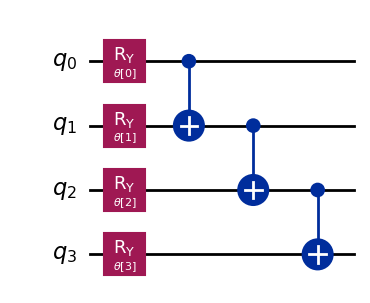

In [1]:
from qiskit.circuit import QuantumCircuit, ParameterVector

def build_circuit(nq):
    pars = ParameterVector(name="$\\theta$", length=nq)
    pqc = QuantumCircuit(nq)
    for i in range(nq):
        pqc.ry(pars[i], i)
    for i in range(nq-1):
        pqc.cx(i, i+1)
    return pqc, pars

build_circuit(nq=4)[0].draw("mpl")

In [2]:
from qiskit_aer import AerSimulator
from qiskit_symb import Statevector

def aer_simulator(pqc, params, values):
    num_params = len(params)
    circuit = pqc.copy()
    circuit.save_statevector()
    sim = AerSimulator(method="statevector")
    param_bind = {params[i]: values[:,i] for i in range(num_params)}
    result = sim.run(circuit, parameter_binds=[param_bind]).result()
    return [result.data(k)["statevector"].data for k in range(len(values))]

def symb_simulator_eval(pqc):
    statevec = Statevector(pqc)
    return statevec, statevec.to_sympy()

def symb_simulator_lamb(statevec, psi_symb):
    return statevec._lambdify(psi_symb)

def symb_simulator_run(psi_func, values):
    return [psi_func(*values[k,:]) for k in range(len(values))]

In [3]:
import time

def measure_runtime(function, reps):
    runtimes = []
    for _ in range(reps):
        start = time.perf_counter()
        result = function()
        runtimes.append(time.perf_counter() - start)
    return result, runtimes

In [4]:
import numpy as np

num_qubits = np.array([2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
num_samples = 10000

reps = 20

In [5]:
runtimes = {"aer":{}, "symb_eval":{}, "symb_lamb":{}, "symb_run":{}}

for nq in num_qubits:
    pqc, params = build_circuit(nq=nq)
    values = np.random.rand(num_samples, pqc.num_parameters)

    psi1, aer_runtimes = measure_runtime(lambda: aer_simulator(pqc, params=params, values=values), reps)
    runtimes["aer"][nq] = aer_runtimes

    (statevec, psi_symb), symb_eval_runtimes = measure_runtime(lambda: symb_simulator_eval(pqc), reps)
    psi_func, symb_lamb_runtimes = measure_runtime(lambda: symb_simulator_lamb(statevec, psi_symb), reps)
    psi2, symb_run_runtimes = measure_runtime(lambda: symb_simulator_run(psi_func, values=values), reps)
    runtimes["symb_eval"][nq] = symb_eval_runtimes
    runtimes["symb_lamb"][nq] = symb_lamb_runtimes
    runtimes["symb_run"][nq] = symb_run_runtimes

    assert np.allclose(psi1, psi2)

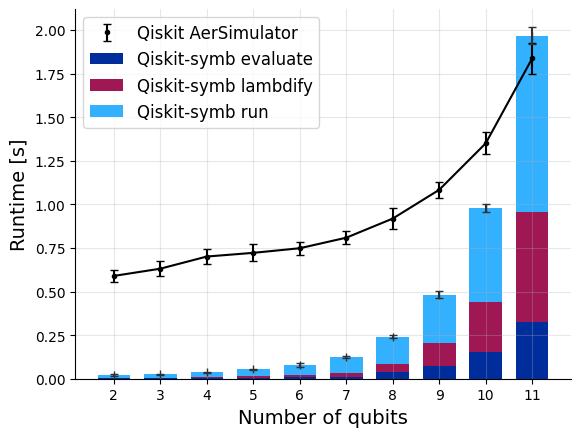

In [10]:
import pylab as plt

xs = num_qubits
aer_mean = np.array([np.mean(runtimes["aer"][x]) for x in xs])
aer_std = np.array([np.std(runtimes["aer"][x]) for x in xs])

symb_eval_mean = np.array([np.mean(runtimes["symb_eval"][x]) for x in xs])
symb_eval_std = np.array([np.std(runtimes["symb_eval"][x]) for x in xs])
symb_lamb_mean = np.array([np.mean(runtimes["symb_lamb"][x]) for x in xs])
symb_lamb_std = np.array([np.std(runtimes["symb_lamb"][x]) for x in xs])
symb_run_mean = np.array([np.mean(runtimes["symb_run"][x]) for x in xs])
symb_run_std = np.array([np.std(runtimes["symb_run"][x]) for x in xs])
symb_total_mean = symb_eval_mean + symb_lamb_mean + symb_run_mean
symb_total_std = symb_eval_std + symb_lamb_std + symb_run_std

fig, ax = plt.subplots()

ax.plot(xs, aer_mean, color="black")
ax.errorbar(xs, aer_mean, aer_std, fmt=".", color="black", capsize=3, label="Qiskit AerSimulator")

width = 0.7
ax.bar(xs, symb_eval_mean, width=width, color="#002D9C", label="Qiskit-symb evaluate")
ax.bar(xs, symb_lamb_mean, width=width, bottom=symb_eval_mean, color="#9F1853", label="Qiskit-symb lambdify")
ax.bar(xs, symb_run_mean, width=width, bottom=symb_eval_mean + symb_lamb_mean, color="#33B1FF", label="Qiskit-symb run")
ax.errorbar(xs, symb_total_mean, yerr=symb_total_std, fmt="|", color="#303030", capsize=3)

ax.set_xticks(xs)
ax.set_xlabel("Number of qubits", fontsize=14)
ax.set_ylabel("Runtime [s]", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.show()